# BabyView vs Things: Exemplar Distance by Category

**Goal:** For selected categories, sample the **top 12 BabyView exemplars** (by similarity to the Things category centroid) and **12 Things exemplars**, then measure how far BabyView exemplars are from Things exemplars within the same category.

**Data:** BabyView uses **original** per-image embeddings from `yoloe_cdi_embeddings` (e.g. `clip_embeddings_new` or DINOv3 dir), keeping only rows in the **filtered metadata** list. Things uses per-exemplar embeddings by category. Supports **CLIP** and **DINOv3** via `EMBEDDING_TYPE`.

**Steps:**
1. Load filtered metadata → load BV embeddings from original dir (only those in filtered list); load Things embeddings by category.
2. For each selected category: compute Things centroid → rank BV exemplars by cosine similarity → take top 12 BV; sample 12 Things.
3. Compute mean cosine distance (BV vs Things) per category and visualize.

## Setup and paths

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

SCRIPT_DIR = Path(".").resolve()
PROJECT_ROOT = SCRIPT_DIR.parent.parent

# Embedding type: "clip" or "dinov3" (switch for comparison)
EMBEDDING_TYPE = "clip"
FILTER_THRESHOLD = 0.27

# BabyView: original per-image embeddings (only those in filtered metadata)
YOLOE_CDI_BASE = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings")
BV_EMBEDDINGS_DIRS = {
    "clip": YOLOE_CDI_BASE / "clip_embeddings_new",
    "dinov3": YOLOE_CDI_BASE / "facebook_dinov3-vitb16-pretrain-lvd1689m",
}
BV_EMBEDDINGS_DIR = BV_EMBEDDINGS_DIRS[EMBEDDING_TYPE]

# Filtered list: metadata CSV (only embeddings in this file are used)
FILTERED_METADATA_CSV = PROJECT_ROOT / f"frame_data/merged_frame_detections_with_metadata_filtered-{FILTER_THRESHOLD}.csv"

# Similarity CSV: precomputed cosine similarity per (category, embedding); used to sample top 12 BV.
# Sourced from yoloe_cdi_base (all-frames CSV). Expect columns: category/class_name, embedding id, cosine similarity.
CLIP_SIMILARITY_CSV = YOLOE_CDI_BASE / "clip_image_embeddings_filtered_all_frames_exclude-people_exclude-subject-00270001.csv"

# Things: per-exemplar by category (same layout as exemplar_variability_analyses)
THINGS_BASE = Path("/ccn2/dataset/babyview/outputs_20250312")
THINGS_EMBEDDINGS_DIRS = {
    "clip": THINGS_BASE / "things_bv_overlapping_categories_corrected/embeddings/image_embeddings/clip_image_embeddings_npy_by_category",
    "dinov3": THINGS_BASE / "image_embeddings/things_bv_overlapping_categories_corrected/facebook_dinov3-vitb16-pretrain-lvd1689m",
}
THINGS_EMBEDDINGS_DIR = THINGS_EMBEDDINGS_DIRS[EMBEDDING_TYPE]

CATEGORIES_FILE = PROJECT_ROOT / "data/things_bv_overlap_categories_exclude_zero_precisions.txt"
EXCLUDED_SUBJECT = "00270001"
MIN_EXEMPLARS = 2
N_TOP_BV = 12
N_THINGS = 12

# Selected categories to analyze (edit this list as needed)
SELECTED_CATEGORIES = [
    "apple", "cat", "dog", "ball", "car", "chair", "cup", "book",
    "banana", "bird", "bottle", "tree"
]

## Load allowed categories and embeddings

In [2]:
def load_allowed_categories(path):
    if path is None or not Path(path).exists():
        return None
    with open(path) as f:
        return set(line.strip().lower() for line in f if line.strip())

allowed_categories = load_allowed_categories(CATEGORIES_FILE)
# Restrict to selected and allowed
categories_to_use = [c for c in SELECTED_CATEGORIES if c in allowed_categories] if allowed_categories else SELECTED_CATEGORIES
print(f"Categories to analyze: {len(categories_to_use)} — {categories_to_use}")

Categories to analyze: 12 — ['apple', 'cat', 'dog', 'ball', 'car', 'chair', 'cup', 'book', 'banana', 'bird', 'bottle', 'tree']


In [3]:
def load_filtered_metadata(metadata_csv, excluded_subject=None):
    """Load filtered metadata; return DataFrame with original_embedding_name, class_name (lower), subject_id_norm, age_mo (int)."""
    df = pd.read_csv(metadata_csv, usecols=["original_embedding_name", "class_name", "subject_id", "age_mo"],
                     dtype={"subject_id": str, "class_name": str}, na_values=[], keep_default_na=False)
    df = df.dropna(subset=["original_embedding_name", "class_name"])
    df["class_name"] = df["class_name"].str.strip().str.lower()
    df["subject_id_norm"] = df["subject_id"].astype(str).str.strip().str.lstrip("S")
    df["age_mo"] = pd.to_numeric(df["age_mo"], errors="coerce").fillna(-1).astype(int)
    if excluded_subject:
        df = df[df["subject_id_norm"] != excluded_subject]
    df = df.drop_duplicates(subset=["original_embedding_name"], keep="first")
    return df


def load_bv_embeddings_from_filtered(embeddings_dir, metadata_csv, allowed_categories=None, excluded_subject=None, min_exemplars=2):
    """Load BV from original embedding dir, only for rows in filtered metadata. Returns category_embeddings, category_exemplar_ids."""
    embeddings_dir = Path(embeddings_dir)
    if not embeddings_dir.exists():
        raise FileNotFoundError(f"BV embeddings dir not found: {embeddings_dir}")
    meta = load_filtered_metadata(metadata_csv, excluded_subject=excluded_subject)
    # Group by class_name: category -> list of (original_embedding_name, subject_id_norm, age_mo)
    cat_to_rows = meta.groupby("class_name", sort=False).apply(
        lambda g: list(zip(g["original_embedding_name"], g["subject_id_norm"], g["age_mo"]))
    ).to_dict()
    category_embeddings = {}
    category_exemplar_ids = {}
    for cat_name, rows in cat_to_rows.items():
        if allowed_categories is not None and cat_name not in allowed_categories:
            continue
        embs, ids = [], []
        cat_folder = embeddings_dir / cat_name
        if not cat_folder.exists():
            for d in embeddings_dir.iterdir():
                if d.is_dir() and d.name.lower() == cat_name:
                    cat_folder = d
                    break
        for emb_name, sid, age_mo in rows:
            path = cat_folder / emb_name
            if not path.exists():
                continue
            try:
                e = np.load(path)
                e = np.asarray(e, dtype=np.float64).flatten()
                embs.append(e)
                ids.append((sid, age_mo))
            except Exception:
                continue
        if len(embs) >= min_exemplars:
            category_embeddings[cat_name] = np.array(embs)
            category_exemplar_ids[cat_name] = ids
    return category_embeddings, category_exemplar_ids

bv_embeddings, bv_ids = load_bv_embeddings_from_filtered(
    BV_EMBEDDINGS_DIR,
    FILTERED_METADATA_CSV,
    allowed_categories=allowed_categories,
    excluded_subject=EXCLUDED_SUBJECT,
    min_exemplars=MIN_EXEMPLARS,
)
print(f"Embedding type: {EMBEDDING_TYPE}, BV dir: {BV_EMBEDDINGS_DIR}")
print(f"Loaded BV: {len(bv_embeddings)} categories (from filtered list)")

/tmp/ipykernel_3321332/4072490267.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_to_rows = meta.groupby("class_name", sort=False).apply(


Embedding type: clip, BV dir: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_new
Loaded BV: 163 categories (from filtered list)


In [4]:
def load_things_embeddings_from_dir(dir_path, allowed_categories=None, min_exemplars=2):
    """Load Things from dir: {dir_path}/{category}/*.npy (CLIP or DINOv3). Returns category_embeddings, category_exemplar_ids."""
    dir_path = Path(dir_path)
    if not dir_path.exists():
        raise FileNotFoundError(f"Things dir not found: {dir_path}")
    category_embeddings = {}
    category_exemplar_ids = {}
    for cat_folder in sorted(dir_path.iterdir()):
        if not cat_folder.is_dir():
            continue
        cat_name = cat_folder.name
        if allowed_categories is not None and cat_name not in allowed_categories:
            continue
        embs, ids = [], []
        for f in sorted(cat_folder.glob("**/*.npy")):
            try:
                e = np.load(f)
                e = np.asarray(e, dtype=np.float64).flatten()
                embs.append(e)
                ids.append((f.stem, None))
            except Exception:
                continue
        if len(embs) >= min_exemplars:
            category_embeddings[cat_name] = np.array(embs)
            category_exemplar_ids[cat_name] = ids
    return category_embeddings, category_exemplar_ids

things_embeddings, things_ids = load_things_embeddings_from_dir(
    THINGS_EMBEDDINGS_DIR,
    allowed_categories=allowed_categories,
    min_exemplars=MIN_EXEMPLARS,
)
print(f"Loaded Things: {len(things_embeddings)} categories ({EMBEDDING_TYPE})")

Loaded Things: 162 categories (clip)


## Load similarity CSV and filtered-list cross-reference

Read cosine similarity from the all-frames CSV in `yoloe_cdi_base` (`clip_image_embeddings_filtered_all_frames_exclude-people_exclude-subject-00270001.csv`), then sample top 12 per category and verify each is in the filtered metadata list.

In [ ]:
# Load similarity CSV (expect columns: category/class_name, embedding id, cosine similarity)
sim_df = pd.read_csv(CLIP_SIMILARITY_CSV)
# Normalize column names (allow cosine_similarity/similarity/sim, class_name/category, original_embedding_name/embedding_name)
sim_col = next((c for c in ["cosine_similarity", "similarity", "sim", "cos_sim"] if c in sim_df.columns), None)
cat_col = next((c for c in ["class_name", "category", "cat"] if c in sim_df.columns), None)
emb_col = next((c for c in ["original_embedding_name", "embedding_name", "embedding_id", "embedding"] if c in sim_df.columns), None)
if sim_col is None or cat_col is None or emb_col is None:
    raise ValueError(f"Similarity CSV must have similarity, category, and embedding-id columns. Found: {list(sim_df.columns)}")
sim_df["class_name"] = sim_df[cat_col].astype(str).str.strip().str.lower()
sim_df["embedding_name"] = sim_df[emb_col].astype(str).str.strip()
sim_df["embedding_name"] = sim_df["embedding_name"].apply(lambda x: x if x.endswith(".npy") else f"{x}.npy")
sim_df["sim_value"] = pd.to_numeric(sim_df[sim_col], errors="coerce")

# Filtered list: (class_name, original_embedding_name) in merged_frame_detections_filtered, exclude subject
meta = load_filtered_metadata(FILTERED_METADATA_CSV, excluded_subject=EXCLUDED_SUBJECT)
meta["original_embedding_name"] = meta["original_embedding_name"].astype(str).str.strip()
meta["original_embedding_name"] = meta["original_embedding_name"].apply(lambda x: x if x.endswith(".npy") else f"{x}.npy")
filtered_set = set(zip(meta["class_name"].values, meta["original_embedding_name"].values))
# Lookup (class_name, original_embedding_name) -> (subject_id_norm, age_mo) for bv_top12_ids
meta_key = meta.set_index(["class_name", "original_embedding_name"]).sort_index()
print(f"Similarity CSV: {len(sim_df)} rows, columns used: sim={sim_col}, cat={cat_col}, emb={emb_col}")
print(f"Filtered set size (excl. subject {EXCLUDED_SUBJECT}): {len(filtered_set)}")

## Sample top 12 BV by CLIP similarity to Things centroid; sample 12 Things

In [5]:
# Sample top 12 BV per category from similarity CSV; keep only rows in filtered list; load those embeddings
def _cat_folder(embeddings_dir, cat_name):
    p = Path(embeddings_dir) / cat_name
    if p.exists():
        return p
    for d in Path(embeddings_dir).iterdir():
        if d.is_dir() and d.name.lower() == cat_name:
            return d
    return p

results = []
bv_top12_embs = {}
things_12_embs = {}
bv_ids = {}  # cat -> list of (subject_id_norm, age_mo) for the sampled 12

for cat in categories_to_use:
    if cat not in things_embeddings:
        continue
    th_X = things_embeddings[cat]
    n_th_take = min(N_THINGS, th_X.shape[0])
    if n_th_take < 2:
        continue
    # From similarity CSV: rows for this category, in filtered set, sorted by sim desc, take top 12
    cat_sim = sim_df[sim_df["class_name"] == cat].dropna(subset=["sim_value"])
    cat_sim = cat_sim[cat_sim.apply(lambda r: (r["class_name"], r["embedding_name"]) in filtered_set, axis=1)]
    top12 = cat_sim.nlargest(N_TOP_BV, "sim_value")
    if len(top12) < 2:
        continue
    # Load embeddings for the selected exemplars
    cat_folder = _cat_folder(BV_EMBEDDINGS_DIR, cat)
    embs_list = []
    ids_list = []
    for _, row in top12.iterrows():
        emb_name = row["embedding_name"]
        path = cat_folder / emb_name
        if not path.exists():
            continue
        try:
            e = np.load(path)
            e = np.asarray(e, dtype=np.float64).flatten()
            embs_list.append(e)
            key = (row["class_name"], emb_name)
            sid = str(meta_key.loc[key, "subject_id_norm"])
            age_mo = int(meta_key.loc[key, "age_mo"])
            ids_list.append((sid, age_mo))
        except Exception:
            continue
    if len(embs_list) < 2:
        continue
    bv_top12_embs[cat] = np.array(embs_list)
    things_12_embs[cat] = th_X[:n_th_take]
    bv_ids[cat] = ids_list
    n_in_filtered = len(top12)
    results.append({
        "category": cat,
        "n_bv_sampled": len(embs_list),
        "n_in_filtered": n_in_filtered,
        "n_things_sampled": n_th_take,
        "bv_mean_sim_to_centroid": float(top12["sim_value"].iloc[: len(embs_list)].mean()),
    })

df_sample = pd.DataFrame(results)
print("Top 12 BV from similarity CSV (cross-referenced with filtered list):")
print(df_sample.to_string())
if "n_in_filtered" in df_sample.columns:
    print(f"\nAll sampled embeddings are in the filtered list: {(df_sample['n_bv_sampled'] == df_sample['n_in_filtered']).all()}")

   category  n_bv_sampled  n_things_sampled  bv_mean_sim_to_centroid
0     apple            12                11                 0.838582
1       cat            12                12                 0.890771
2       dog            12                 9                 0.837546
3      ball            12                12                 0.875119
4     chair            12                 9                 0.897068
5       cup            12                12                 0.875481
6      book            12                11                 0.887764
7    banana            12                12                 0.909453
8      bird            12                12                 0.776520
9    bottle            12                11                 0.849516
10     tree            12                10                 0.879123


## Distance: how far are BV exemplars from Things exemplars within category?

In [6]:
# For each category: pairwise cosine similarity between 12 BV and 12 Things → mean cosine distance (1 - sim)
distance_rows = []
for cat in bv_top12_embs:
    bv_12 = bv_top12_embs[cat]
    th_12 = things_12_embs[cat]
    sim_matrix = cosine_similarity(bv_12, th_12)  # (12, 12)
    mean_sim = float(np.mean(sim_matrix))
    mean_cos_dist = 1.0 - mean_sim
    # Also: mean distance from each BV to its nearest Things exemplar
    max_sim_per_bv = np.max(sim_matrix, axis=1)
    mean_nearest_sim = float(np.mean(max_sim_per_bv))
    mean_nearest_cos_dist = 1.0 - mean_nearest_sim
    distance_rows.append({
        "category": cat,
        "mean_bv_things_cosine_similarity": mean_sim,
        "mean_bv_things_cosine_distance": mean_cos_dist,
        "mean_bv_to_nearest_things_similarity": mean_nearest_sim,
        "mean_bv_to_nearest_things_distance": mean_nearest_cos_dist,
    })

df_dist = pd.DataFrame(distance_rows)
print("BV–Things distance per category (cosine distance = 1 - cosine similarity):")
print(df_dist.to_string())
print(f"\nOverall mean cosine distance (BV exemplars vs Things exemplars): {df_dist['mean_bv_things_cosine_distance'].mean():.4f}")

BV–Things distance per category (cosine distance = 1 - cosine similarity):
   category  mean_bv_things_cosine_similarity  mean_bv_things_cosine_distance  mean_bv_to_nearest_things_similarity  mean_bv_to_nearest_things_distance
0     apple                          0.787237                        0.212763                              0.835068                            0.164932
1       cat                          0.800986                        0.199014                              0.859592                            0.140408
2       dog                          0.739774                        0.260226                              0.803309                            0.196691
3      ball                          0.753416                        0.246584                              0.829941                            0.170059
4     chair                          0.812289                        0.187711                              0.850866                            0.149134
5       cup  

## Visualize: BV–Things distance by category

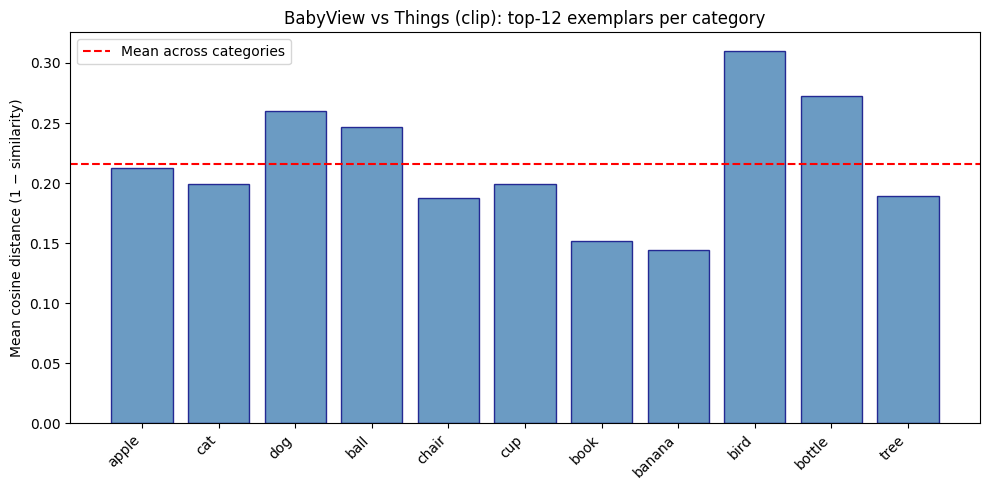

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
cats = df_dist["category"].values
dists = df_dist["mean_bv_things_cosine_distance"].values
ax.bar(range(len(cats)), dists, color="steelblue", edgecolor="navy", alpha=0.8)
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=45, ha="right")
ax.set_ylabel("Mean cosine distance (1 − similarity)")
ax.set_title(f"BabyView vs Things ({EMBEDDING_TYPE}): top-12 exemplars per category")
ax.axhline(df_dist["mean_bv_things_cosine_distance"].mean(), color="red", linestyle="--", label="Mean across categories")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Save summary CSV (optional)
out_csv = SCRIPT_DIR / f"bv_things_exemplar_distance_by_category_{EMBEDDING_TYPE}.csv"
df_dist.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/bv_things_exemplar_distance_by_category_clip.csv
